In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.lines import Line2D
from model import sample_instance, Graph
from bp import bp_corr2
from spectral import spectral_corr2
from low_degree import low_degree_corr





## Graph Visualization

In [10]:
def draw_graph(
    graph,
    source,
    target,
    ax=None,
    seed=0,
    title=None,
    positions=None,
):
    if source not in graph.nodes:
        raise ValueError("The source is not in the graph.")

    if target not in graph.nodes:
        raise ValueError("The target is not in the graph.")

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    nx_graph = nx.MultiGraph()
    nx_graph.add_nodes_from(graph.nodes)

    for edge_id, edge in enumerate(graph.edges):
        nx_graph.add_edge(edge.u, edge.v, key=edge_id)

    if positions is None:
        positions = nx.spring_layout(nx_graph, seed=seed)

    ordinary_nodes = [
        node
        for node in graph.nodes
        if node not in {source, target}
    ]

    nx.draw_networkx_edges(
        nx_graph,
        positions,
        ax=ax,
        width=1.8,
        edge_color="gray",
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=ordinary_nodes,
        ax=ax,
        node_size=700,
        node_color="lightblue",
        edgecolors="black",
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=[source],
        ax=ax,
        node_size=850,
        node_color="mediumseagreen",
        edgecolors="black",
        linewidths=2,
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=[target],
        ax=ax,
        node_size=850,
        node_color="darkorange",
        edgecolors="black",
        linewidths=2,
    )

    nx.draw_networkx_labels(
        nx_graph,
        positions,
        ax=ax,
        font_size=10,
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="mediumseagreen",
            markeredgecolor="black",
            markersize=11,
            label=f"Source: {source}",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="darkorange",
            markeredgecolor="black",
            markersize=11,
            label=f"Sink: {target}",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="best",
        frameon=False,
    )

    if title is not None:
        ax.set_title(title)

    ax.set_axis_off()
    return ax

## Trees and Paths

In [5]:
def make_path(p_values):
    graph = Graph()

    for i, p in enumerate(p_values):
        graph.add_edge(i, i + 1, p)

    return graph, 0, len(p_values)

In [6]:
p_values = [0.2, 0.2, 0.2, 0.2]

path, s, t = make_path(p_values)

<Axes: >

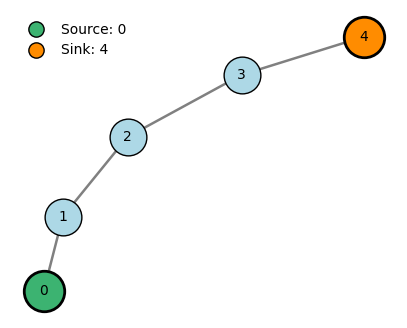

In [12]:
draw_graph(path, s, t)

In [54]:
result_bp = bp_corr2(path, s, t, n_samples=5000, seed=0)['corr2']
result_spectral = spectral_corr2(path, s, t, alg="naive", n_samples=5000, seed=0)['corr2']
result_low_degree = low_degree_corr(path, 4, s, t)

In [55]:
print(f"BP estimate: {result_bp:.4f}")
print(f"Naive Spectral: {result_spectral:.4f}")
print(f"Low-degre: {result_low_degree:.4f}")

BP estimate: 0.0184
Naive Spectral: 0.0184
Low-degre: 0.0168


## S-P graphs

In [ ]:
def make_parallel_branch_graph(m=3, n=3, p=0.1):
    graph = Graph()
    observations = []
    positions = {
        "s": (0, 0),
        "t": (8, 0),
        "a": (4, -3.5),
    }

    # The displayed observation on (s, a) is -1.
    graph.add_edge("s", "a", p)
    observations.append(-1)

    # Paths s -- c_i -- d_i -- t.
    top_heights = np.linspace(2.5, 0.5, m)

    for i, height in enumerate(top_heights, start=1):
        c = f"c_{i}"
        d = f"d_{i}"

        positions[c] = (3, height)
        positions[d] = (5, height)

        graph.add_edge("s", c, p)
        observations.append(1)

        graph.add_edge(c, d, p)
        observations.append(1)

        graph.add_edge(d, "t", p)
        observations.append(1)

    # Paths a -- b_j -- t.
    a_position = np.array(positions["a"], dtype=float)
    t_position = np.array(positions["t"], dtype=float)

    offsets = np.linspace(0.8, -0.8, n)

    for j, offset in enumerate(offsets, start=1):
        b = f"b_{j}"
        fraction = j / (n + 1)

        base_position = (
            (1 - fraction) * a_position
            + fraction * t_position
        )

        positions[b] = tuple(
            base_position + np.array([0, offset])
        )

        graph.add_edge("a", b, p)
        observations.append(1)

        graph.add_edge(b, "t", p)
        observations.append(1)

    return (
        graph,
        "s",
        "t",
        np.array(observations, dtype=int),
        positions,
    )

## Grids

## Misc